In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gseapy as gp
import os
import pickle
import importlib

import subcluster_funcs as funcs
importlib.reload(funcs)
sc._settings.settings._vector_friendly=True

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
post_subclustering_dir = "../post_subcluster_annotation/"
os.makedirs(post_subclustering_dir, exist_ok=True)
plots_dir = "plots_dir/"
os.makedirs(plots_dir, exist_ok=True)

In [3]:
cell_type = "Endothelial"

In [4]:
%%time
adata = sc.read_h5ad("../continuous_cov_corrected_no_scvi/" + cell_type  + ".h5ad")

CPU times: user 2min 4s, sys: 26.2 s, total: 2min 30s
Wall time: 3min 24s


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>

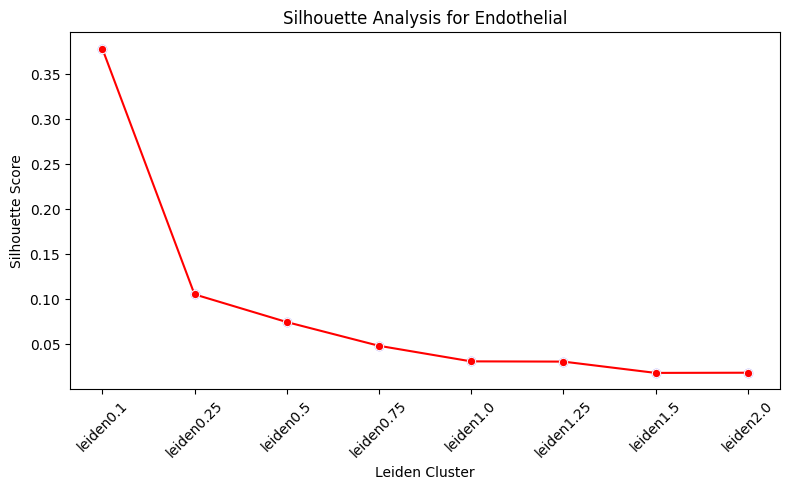

In [5]:
funcs.silhouette(adata, silhouette_res_dir = "../silhouette_res_scVI/", cell_type = cell_type)

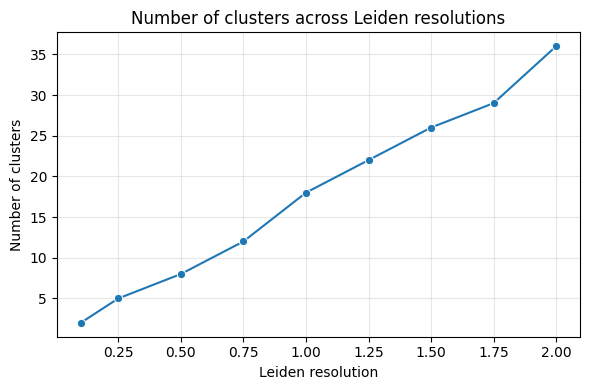

In [6]:
cluster_df, fig = funcs.leiden_resolution_summary(adata)

### Use Leiden 0.5

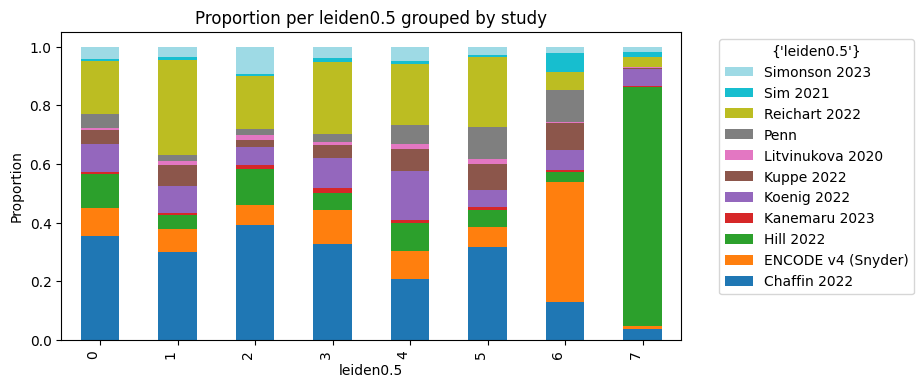

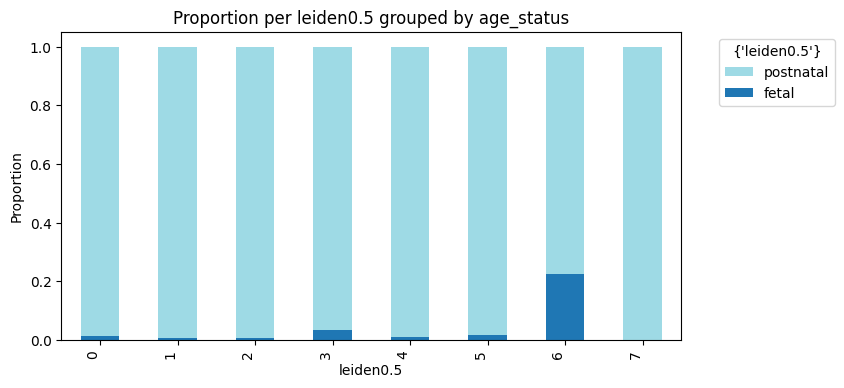

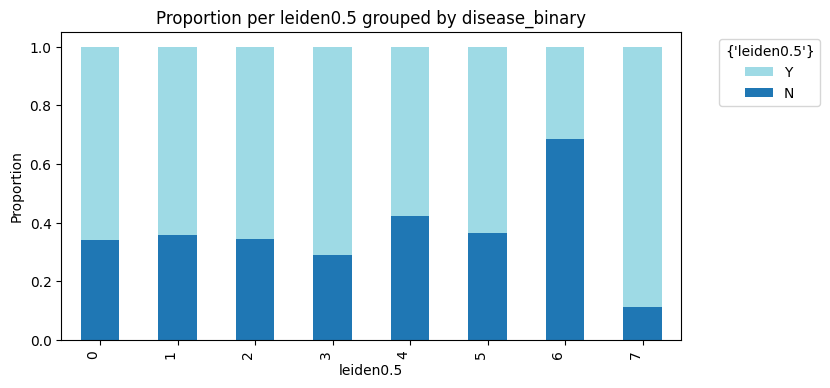

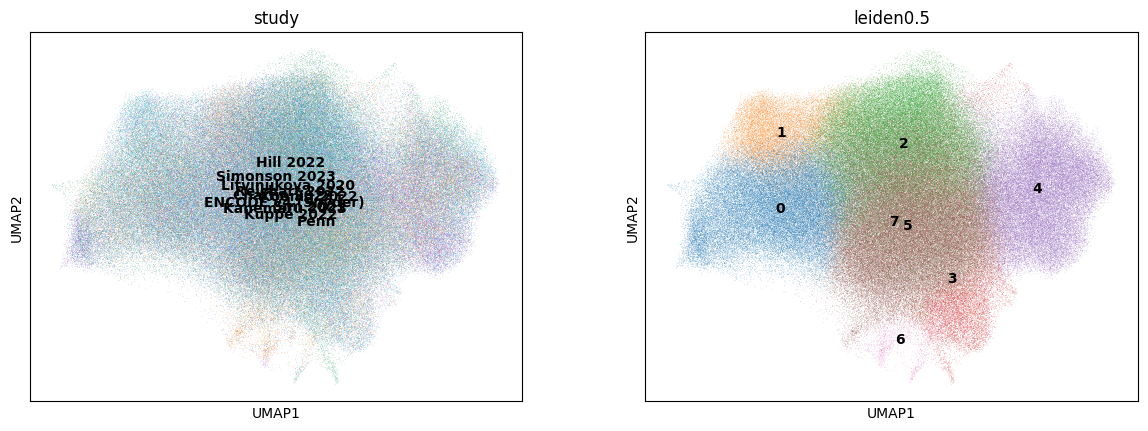

/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean

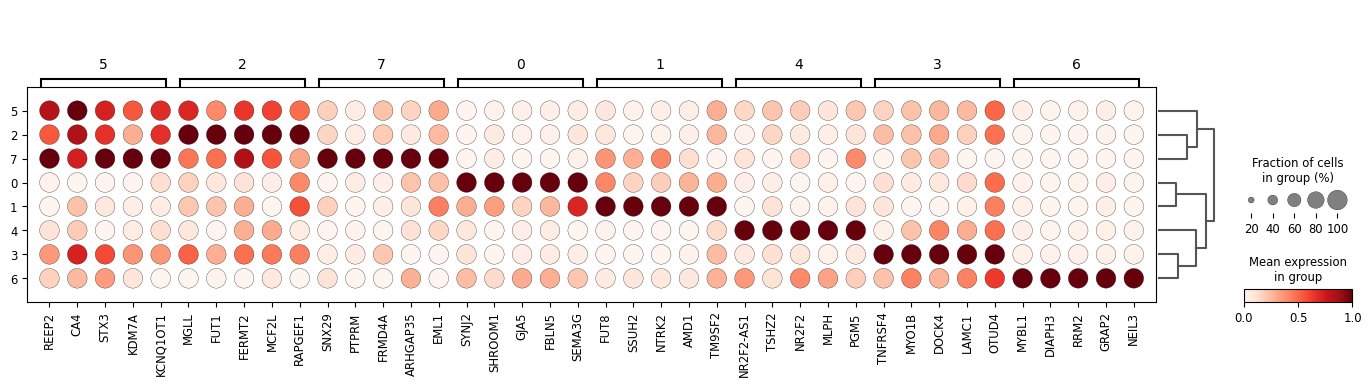

Counter({'5': 96864, '2': 70917, '0': 54904, '4': 54772, '3': 20615, '1': 16705, '6': 1941, '7': 406})
CPU times: user 3min 10s, sys: 1h 15min 8s, total: 1h 18min 18s
Wall time: 2min 1s


['leiden0.5',
 AnnData object with n_obs × n_vars = 317124 × 16115
     obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'total_UMI', 'log10_UMI', 'endo_score', 'cm_score', 'fib_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'l

In [7]:
%%time
leiden_key = "leiden0.5"
funcs.specify_leiden_subclustering(adata=adata, leiden=leiden_key)

In [8]:
adata.obs['age_disease'] = adata.obs['age_status'].astype(str) + ":" + adata.obs['disease'].astype(str)

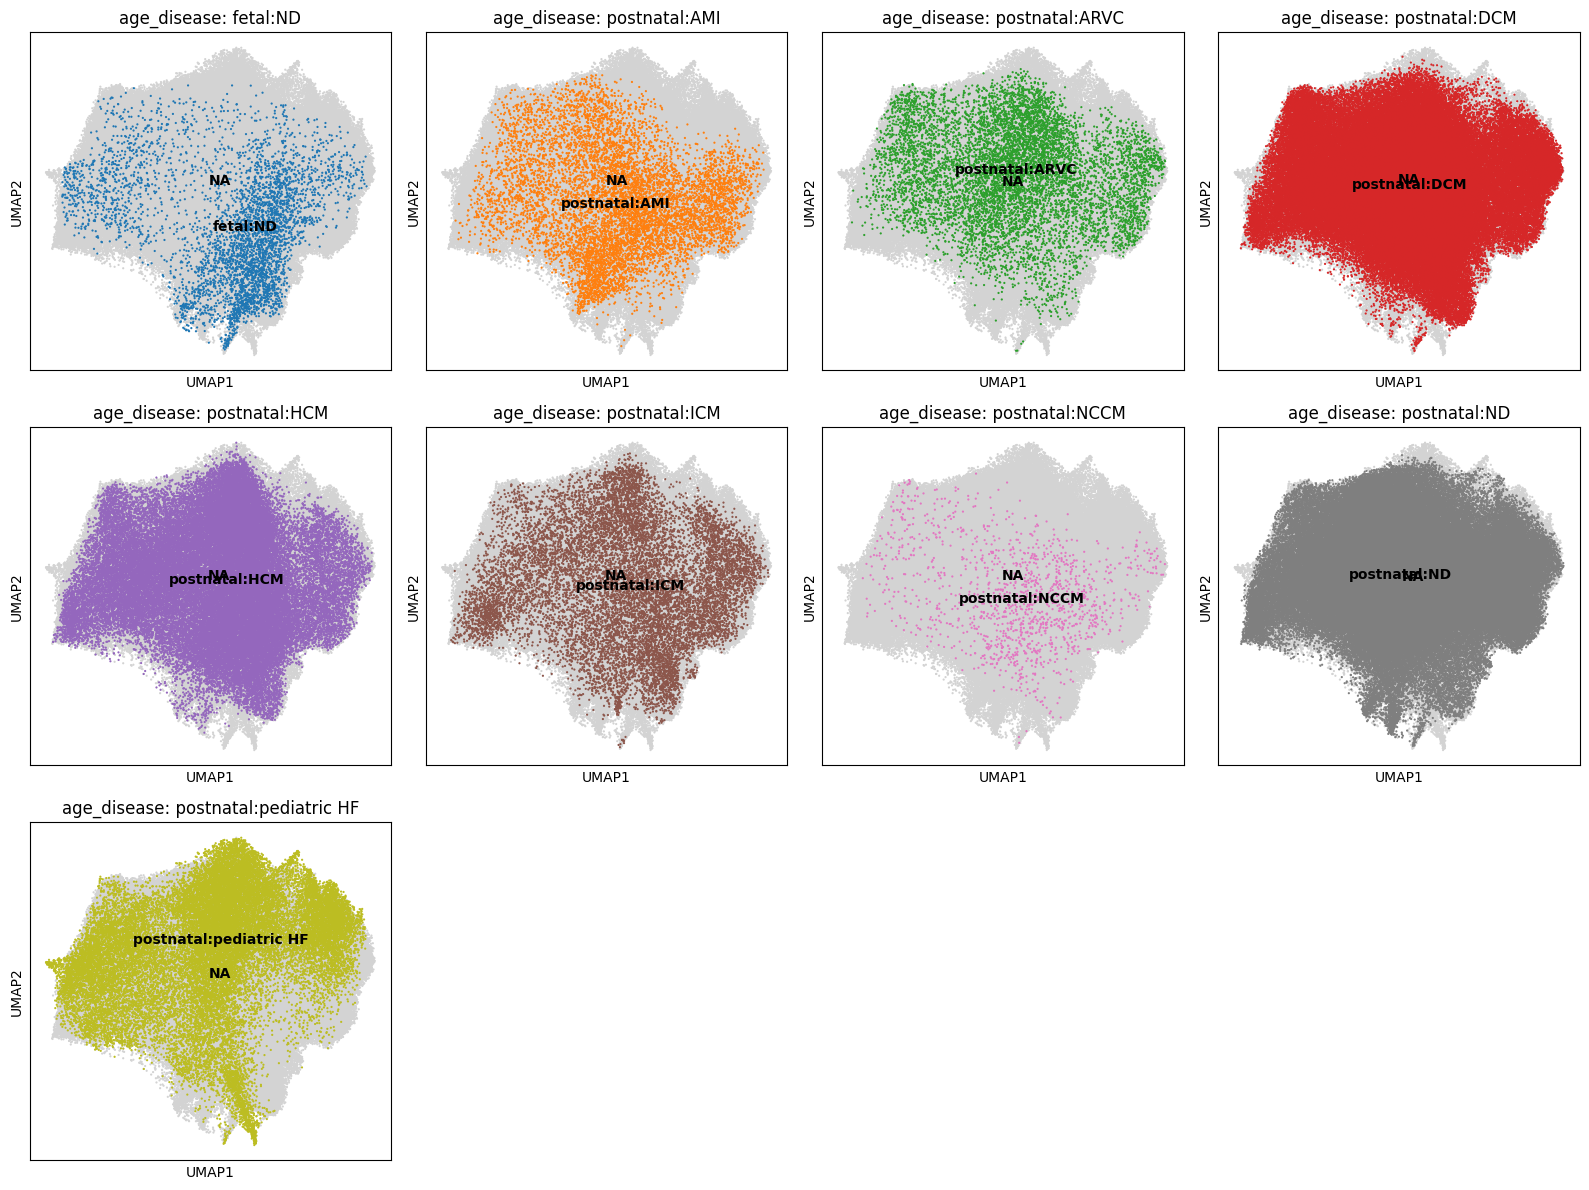

In [9]:
funcs.plot_umap_by_cluster(adata, metadata_key = "age_disease")

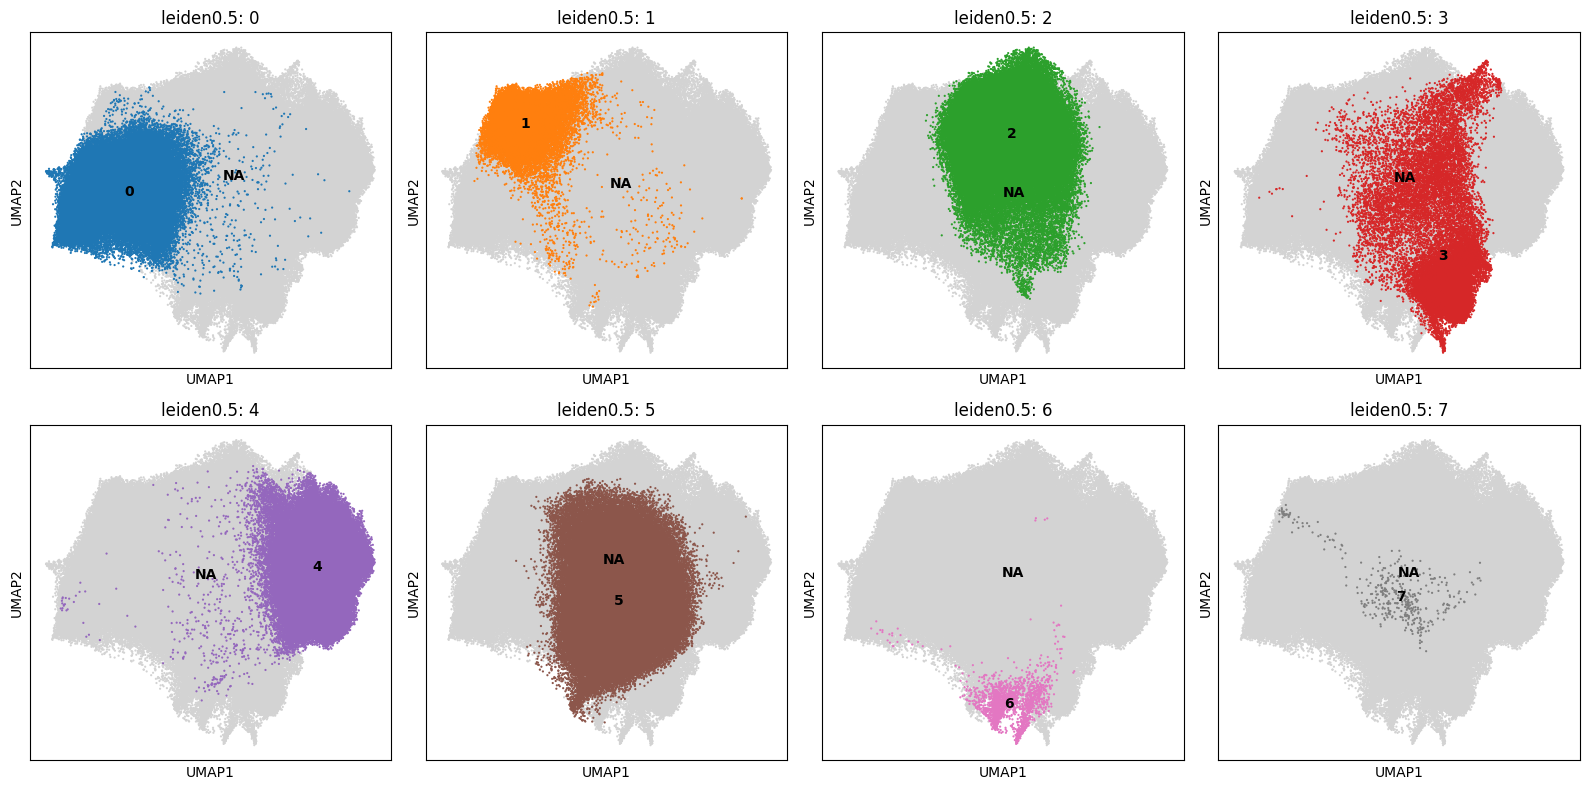

In [10]:
funcs.plot_umap_by_cluster(adata, metadata_key = leiden_key)

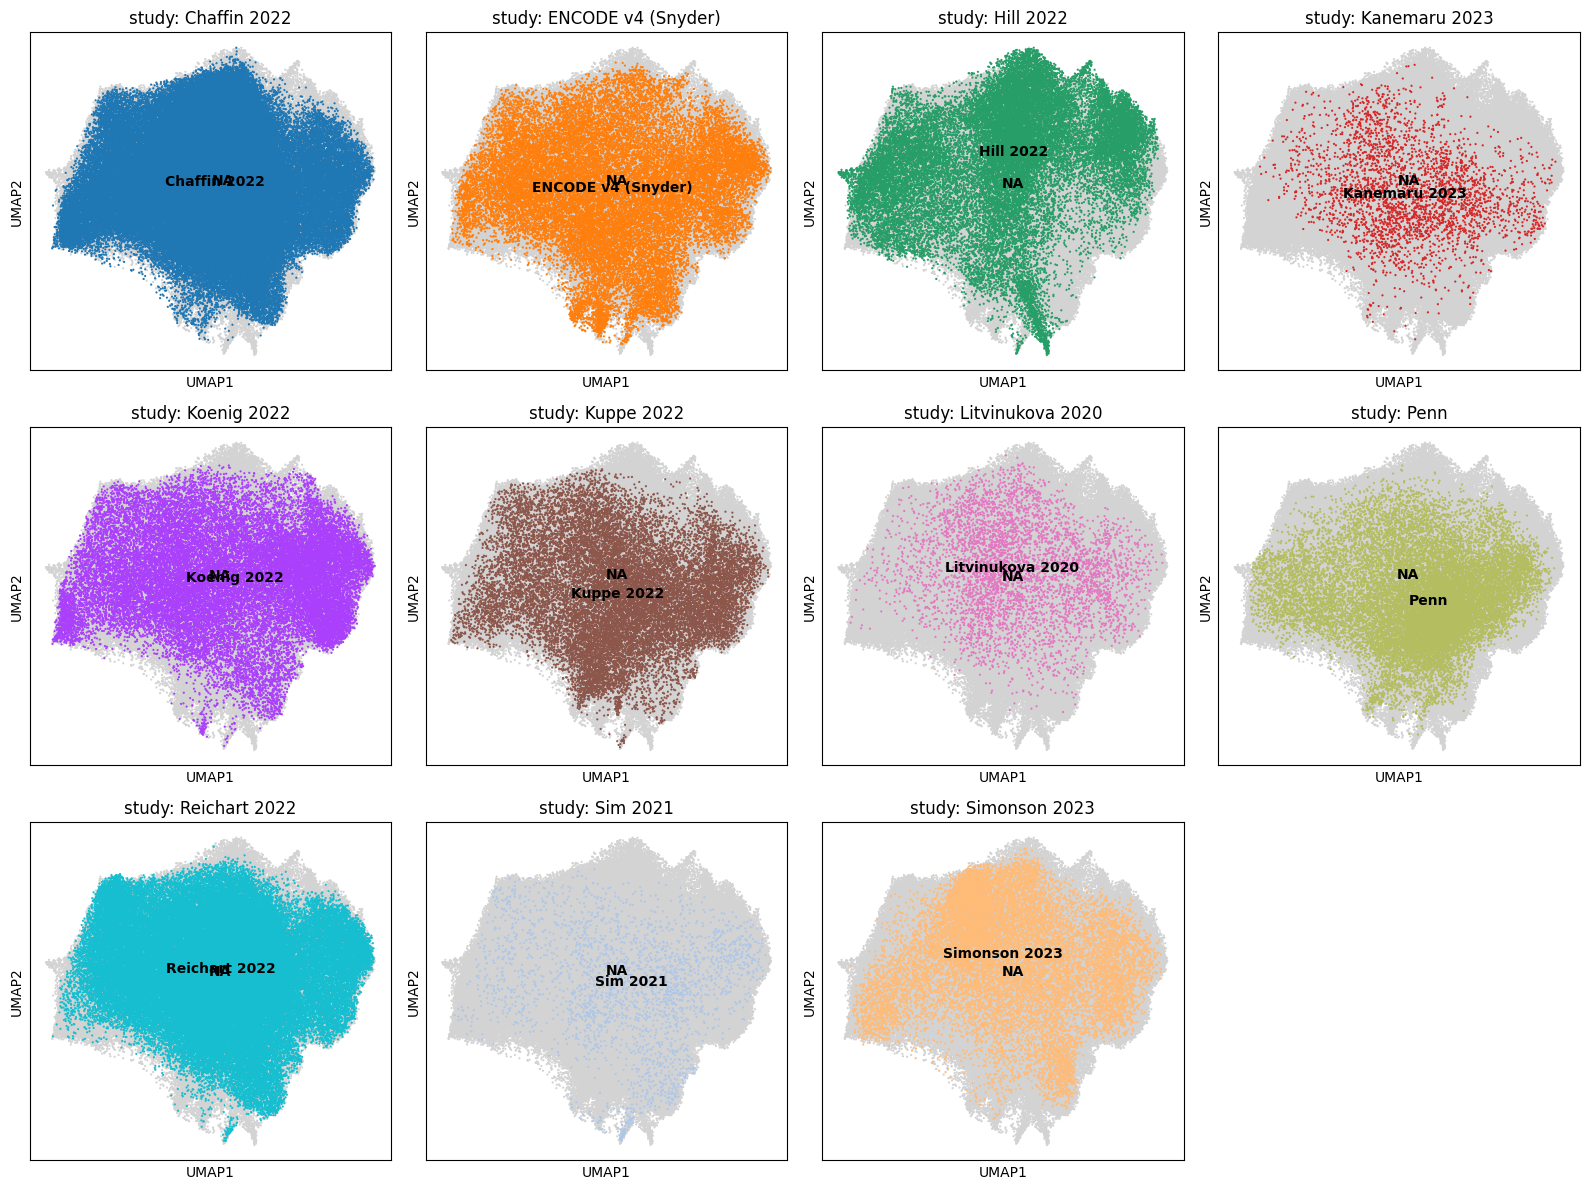

In [11]:
funcs.plot_umap_by_cluster(adata, metadata_key = "study")

### Examine enrichment along metadata categories

/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/aggregated_analysis/v4_subclustering_analysis/examine_covariates/perform_annotation/subcluster_funcs.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, sub in metadata.groupby(cluster_label):


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>


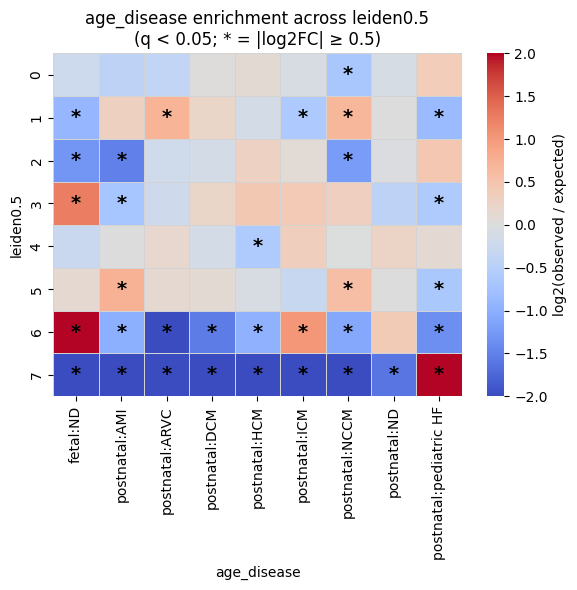

In [12]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=adata.obs,
    cluster_label=leiden_key,
    study_col="age_disease",
    min_cells=50, figsize_tuple = (6,6)
)

### Marker gene / ORA analysis

In [64]:
#sc.get.rank_genes_groups_df(adata, group="3").head(60)['names']

In [62]:
#sc.pl.umap(adata, color = "NOS2", cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True))

Processing Cluster 0... Success.
Processing Cluster 1... Success.
Processing Cluster 2... Success.
Processing Cluster 3... Success.
Processing Cluster 4... Success.
Processing Cluster 5... Success.
Processing Cluster 6... Success.
Processing Cluster 7... Success.


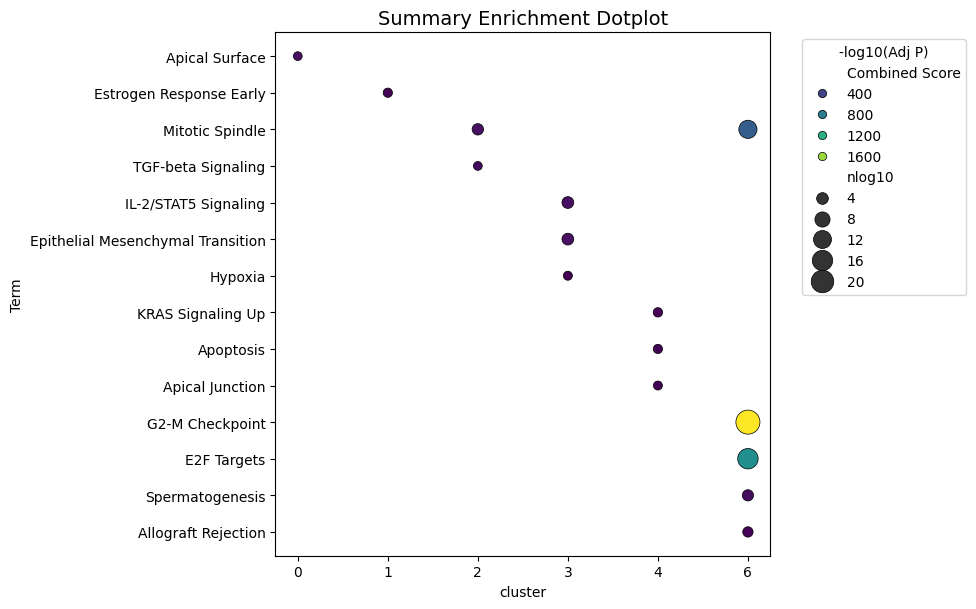

In [14]:
funcs.plot_all_cluster_enrichment(
     adata, cluster_key=leiden_key, 
     gene_sets=["MSigDB_Hallmark_2020"], outdir=None,top_n=100)

- Cluster 0 are arterial endothelial cells: GJA5/EFNB2/BMX
- Cluster 1 are arteriole endothelial cells with Notch signature: HEY1/ALPL (arteriole-enriched)/PTGDR (prostaglandin signaling)
- Cluster 2 are capillary endothelial cells: TCF15/FLT1/CDKN1C
- Cluster 3 is fetal-enriched and disease-enriched; venous endothelial cells: NRP2/PGF/COL4A1
- Cluster 4 are also venous endothelial cells: NR2F2/SELP/PLAT
- Cluster 5 are capillary endothelial cells: CA4/NDNF/TCF15
- Cluster 6 is fetal-enriched (AURKB/DIAPH3/EZH2)
- Cluster 7 is pediatric HF-enriched, but is a very small cluster; join with cluster 5

### Subcluster annotation

In [66]:
# map each Leiden cluster to detailed subclusters
adata.obs['subcluster'] = adata.obs[leiden_key].map({
    "0": "Arterial",
    "1": "Arteriole",
    "2": "Capillary_1",
    "3": "Activated",
    "4": "Venous",
    "5": "Capillary_2",
    "6": "Fetal-enriched",   
    "7": "Capillary_2"
})

# define order for plotting (can include all detailed subclusters)
subcluster_order = sorted([
    "Activated",
    "Arterial",
    "Arteriole",
    "Capillary_1",
    "Capillary_2",
    "Fetal-enriched",  
    "Venous",
])

adata.obs['subcluster'] = pd.Categorical(
    adata.obs['subcluster'],
    categories=subcluster_order,
    ordered=True
)

# define colors for detailed subclusters
subcluster_colors = {
    "Fetal-enriched": "pink",
    "Capillary_1": "cyan",
    "Capillary_2": "darkcyan",
    "Arterial": "red",
    "Arteriole": "orange",
    "Venous": "darkblue",
    "Activated": "yellow"
}

# apply colors to scanpy
adata.uns['subcluster_colors'] = [subcluster_colors[sc] for sc in subcluster_order]

### Produce plots

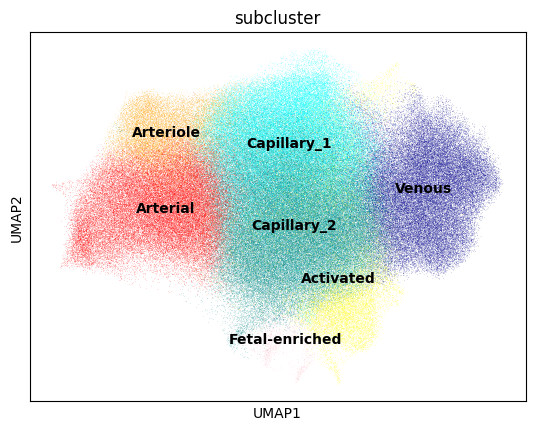

In [67]:
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['subcluster'], legend_loc = "on data", palette=subcluster_colors, show=False)
    plt.savefig(plots_dir + cell_type + "_subclustered.pdf", bbox_inches="tight")

- Cluster 0 are arterial endothelial cells: GJA5/EFNB2/BMX
- Cluster 1 are arteriole endothelial cells with Notch signature: HEY1/ALPL (arteriole-enriched)/PTGDR (prostaglandin signaling)
- Cluster 2 are capillary endothelial cells: TCF15/FLT1/CDKN1C
- Cluster 3 is fetal-enriched and disease-enriched; venous endothelial cells: NRP2/PGF/COL4A1
- Cluster 4 are also venous endothelial cells: NR2F2/SELP/PLAT
- Cluster 5 are capillary endothelial cells: CA4/NDNF/TCF15
- Cluster 6 is fetal-enriched (AURKB/DIAPH3/EZH2)

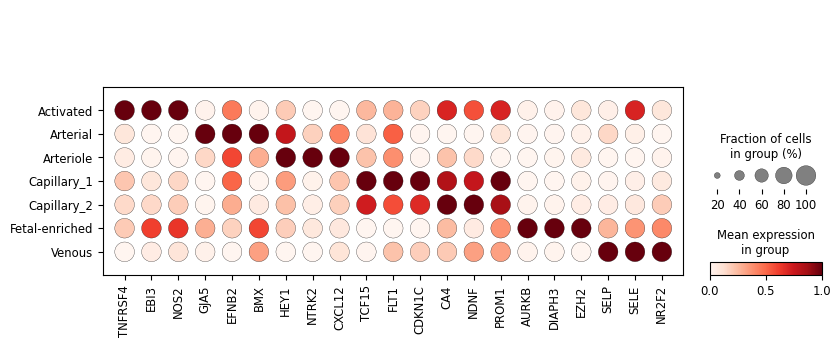

In [69]:
with plt.rc_context(): 
    sc.pl.dotplot(adata, var_names = [ "TNFRSF4", "EBI3", "NOS2",
                                       "GJA5", "EFNB2", "BMX",
                                       "HEY1", "NTRK2", "CXCL12",
                                       "TCF15", "FLT1", "CDKN1C",
                                      "CA4", "NDNF", "PROM1",
                                      "AURKB", "DIAPH3", "EZH2",
                                       "SELP", "SELE", "NR2F2"], 
              groupby = "subcluster", show=False, standard_scale='var')
    plt.savefig(plots_dir + cell_type + "_subclustered_dotplot.pdf", bbox_inches="tight")

### Show enrichments by disease-age status and age group

In [70]:
adata_metadata = adata.obs

disease_filtered_metadata = adata_metadata[~adata_metadata['age_disease'].isin(["postnatal:ARVC", "postnatal:NCCM"])].copy()
for col in disease_filtered_metadata.select_dtypes('category').columns:
    disease_filtered_metadata[col] = disease_filtered_metadata[col].cat.remove_unused_categories()
    
ND_adata_metadata = adata_metadata[adata_metadata['disease_binary'] == "N"].copy()

/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/aggregated_analysis/v4_subclustering_analysis/examine_covariates/perform_annotation/subcluster_funcs.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, sub in metadata.groupby(cluster_label):


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>


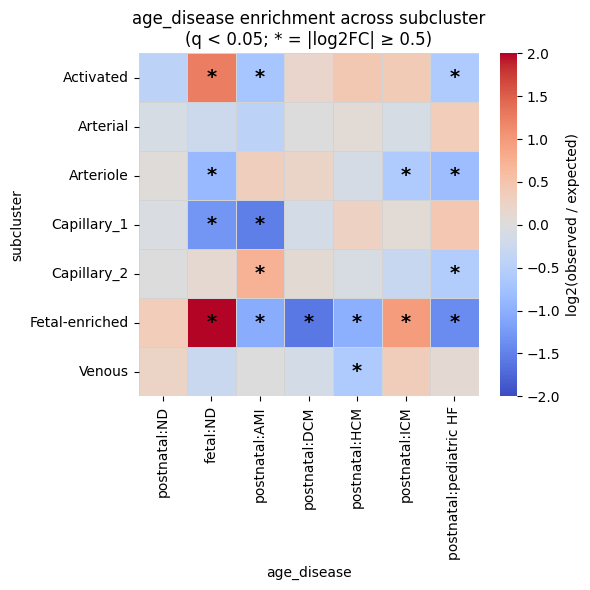

In [71]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=disease_filtered_metadata,
    cluster_label="subcluster",
    study_col="age_disease",
    metadata_order = ['postnatal:ND', 'fetal:ND', 'postnatal:AMI', 'postnatal:DCM', 
                      'postnatal:HCM', 'postnatal:ICM', 'postnatal:pediatric HF'],
    min_cells=50, figsize_tuple = (6,6)
)

plot.savefig(plots_dir + cell_type + "_subcluster_age_disease.pdf")

/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/aggregated_analysis/v4_subclustering_analysis/examine_covariates/perform_annotation/subcluster_funcs.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, sub in metadata.groupby(cluster_label):


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>


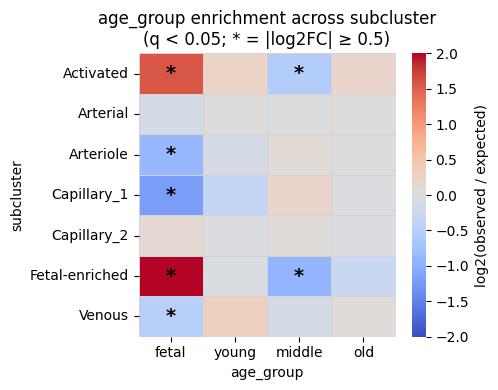

In [72]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=ND_adata_metadata,
    cluster_label="subcluster",
    metadata_order = ["fetal", "young", "middle", "old"],
    study_col="age_group",
    min_cells=50, figsize_tuple = (5,4)
)

plot.savefig(plots_dir + cell_type + "_subcluster_aging.pdf")

In [75]:
subcluster_stats = (
    adata.obs['subcluster']
    .value_counts(normalize=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "subcluster"})
)

subcluster_stats["proportion"] = subcluster_stats["count"] / subcluster_stats["count"].sum()

print(subcluster_stats)

       subcluster  count  proportion
0     Capillary_2  97270    0.306725
1     Capillary_1  70917    0.223625
2        Arterial  54904    0.173131
3          Venous  54772    0.172715
4       Activated  20615    0.065006
5       Arteriole  16705    0.052677
6  Fetal-enriched   1941    0.006121


### Save metadata

In [ ]:
adata.obs.to_csv(post_subclustering_dir + cell_type + "_annotation.csv")